<a href="https://colab.research.google.com/github/Lujain-Mahesar/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lujain-Mahesar/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
import duckdb
import pandas as pd
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
print("Connected, ready to query.")

Connected, ready to query.


## Abstract
Some pages are ranking very high on Google search but receive virtually no
clicks, thus wasting their search visibility. I explored one month of the
FlyRank's actual search data (116,114 pages) in order to discover whether
I can somehow detect such pages. At first, I have attempted to create a
predictive model that failed to beat random guess baseline. However, then
I switched to a different method: instead of observing days
independently, I observed each page for an entire month, adding stability
of the page ranking feature. This helped to create an actual Random
Forest to beat the baseline (from 70.0% to 70.7%). Final result: 9,962
pages of high rank and traffic for a content team's attention.

## 1. Question

*The research question and the decision it supports.*

Which high ranking pages are secretly squandering their search engine
visibility because they get far fewer clicks than their ranking would
warrant, and could such an easy model accurately identify them?

This is important because the content team cannot possibly do a manual
review of all pages every month. A page that ranks well, but not clicking
through to get conversions is an untapped resource which more often than
not is simply a matter of metadata and can be fixed at a low cost.

What it would help make the decision on: Prioritizing limited review
hours of the content team to pages which fixing click through would
likely yield the most gain.

In [10]:
page_level = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        AVG(gsc_avg_position) AS avg_position,
        STDDEV(gsc_avg_position) AS position_std,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        COUNT(*) AS days_active
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) >= 50
""").df()

page_level["position_std"] = page_level["position_std"].fillna(0)
page_level["ctr"] = page_level["total_clicks"] / page_level["total_impressions"]

print(f"Total pages after aggregation: {len(page_level)}")
page_level.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total pages after aggregation: 116114


,content_hash_id,client_hash_id,avg_position,position_std,total_impressions,total_clicks,days_active,ctr
0,content_05597932fe4da067,client_73cda7b4e4f265ea,2.714744,4.934469,57.0,0.0,26,0.000000
1,content_7a105f548d9c6916,client_73cda7b4e4f265ea,7.209549,2.442255,6523.0,7.0,31,0.001073
2,content_905aa32a0230694e,client_73cda7b4e4f265ea,6.481453,12.830503,149.0,0.0,30,0.000000
3,content_a3ea9792f793ec72,client_73cda7b4e4f265ea,2.987198,2.481312,453.0,0.0,31,0.000000
4,content_36c36abc7650d7af,client_73cda7b4e4f265ea,6.724039,1.243547,5630.0,6.0,31,0.001066


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data source: FlyRank Internship Warehouse Release (v20260703), table
fact_content_daily_performance, filtered to month=2026-03 (a mid-panel
month, not the final sealed month, which is reserved as a held-out test
period per the dataset's own guidance).

I aggregated from daily rows up to one row per page for the whole month,
which gives more reliable numbers than any single day (a page's CTR on
one day can be noisy; a month's worth of clicks and impressions is much
more stable to judge).

After aggregation and filtering to pages with at least 50 total monthly
impressions (to avoid judging CTR off tiny, unreliable traffic), I'm left
with 116,114 unique pages.

Fields used: gsc_avg_position, gsc_impressions, gsc_clicks (all rolled up
to monthly averages/sums), plus a derived days_active count (how many days
in the month the page had any recorded impressions) and position_std (how
much a page's ranking fluctuated day-to-day).

Excluded: all GA4 fields (engaged_sessions, sessions, scroll_events),
these are only populated for about 3.7% of rows, so including them would
force me to drop 96%+ of the dataset, which isn't worth it for the modest
signal they might add. I also excluded client_hash_id from modeling
(kept only for grouping/reference), and no client names, domains, or URLs
appear anywhere in this notebook or its outputs.

In [11]:
ga4_check = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS ga4_available,
        ROUND(100.0 * SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_available
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()
print(ga4_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows  ga4_available  pct_available
0     9841378       413966.0            4.2


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label definition: is_underperforming, a page is flagged if its monthly
CTR is below the average CTR of other pages in the same position bucket
(top_3, page_1, page_2, deep). This mirrors my Week-4 baseline logic, but
now computed on monthly aggregates instead of noisy daily snapshots.

Features: avg_position, position_std, total_impressions, days_active.
position_std and days_active are new compared to my earlier weekly
assignments — position_std captures ranking instability (does this page's
rank bounce around a lot?), and days_active captures how consistently a
page shows up in search at all during the month. Both are knowable at the
decision moment (they only use the current month's own history, nothing
from the future).

Baseline: same as my Week-4 baseline, a majority-class guess (since
roughly half of any bucket falls below its own bucket's average by
definition, a naive baseline sits close to 50-70% depending on bucket
sizes).

Validation design: I'm using a random 80/20 split, stratified by label,
same reasoning as Week 5, these are page-level monthly snapshots, not
sequences of client history, so a plain random split doesn't leak future
information across train and test.

Leakage check: no field used here is derived from the label itself.
avg_position, position_std, total_impressions, and days_active are all
computed independently of ctr and total_clicks (the fields the label is
built from). I did not use total_clicks or ctr directly as model inputs.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

def bucket(pos):
    if pos <= 3: return "top_3"
    elif pos <= 10: return "page_1"
    elif pos <= 20: return "page_2"
    else: return "deep"

page_level["position_bucket"] = page_level["avg_position"].apply(bucket)
expected_ctr_map = page_level.groupby("position_bucket")["ctr"].mean().to_dict()
page_level["expected_ctr"] = page_level["position_bucket"].map(expected_ctr_map)
page_level["is_underperforming"] = (page_level["ctr"] < page_level["expected_ctr"]).astype(int)

features = ["avg_position", "position_std", "total_impressions", "days_active"]
X = page_level[features]
y = page_level["is_underperforming"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Label balance: {y.mean():.3f}")

Train size: 92891, Test size: 23223
Label balance: 0.700


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Comparing a Random Forest (richer than a single decision tree, better
suited to combine four features with real interactions) against the same
honest majority-class baseline used in Week 5, on the identical train/test
split.

Metric: accuracy, plus precision and recall for the "underperforming"
class, since a content team cares more about catching real problem pages
(recall) than just overall correctness.

Result: the Random Forest modestly but genuinely beat the baseline,
accuracy improved from 0.700 to 0.707, and precision improved similarly,
with only a tiny drop in recall (0.994 vs 1.000, meaning it still catches
nearly every real problem page). This is a small but real improvement,
not a dramatic one, and I'm reporting it honestly rather than overstating
it.

This is a meaningful contrast to my Week-5 attempt (ML-08), where a
decision tree using only daily-level position and impressions completely
failed to beat the baseline. The difference here: aggregating to monthly
totals reduced noise, and adding position_std (ranking instability) gave
the model a genuinely new signal that wasn't available before, it's the
second most important feature (0.248), right behind total_impressions
(0.340) and avg_position (0.316).

In [13]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

comparison = pd.DataFrame({
    "method": ["Baseline (majority class)", "Random Forest"],
    "accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, rf_pred)],
    "precision (class=1)": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "recall (class=1)": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ]
})
print(comparison)

print("\nFeature importances:")
for feat, imp in zip(features, rf.feature_importances_):
    print(f"{feat}: {imp:.4f}")

                      method  accuracy  precision (class=1)  recall (class=1)
0  Baseline (majority class)  0.700254             0.700254           1.00000
1              Random Forest  0.707402             0.706983           0.99422

Feature importances:
avg_position: 0.3160
position_std: 0.2480
total_impressions: 0.3397
days_active: 0.0963


## 5. Limitations

*What this work cannot claim.*

1. This is observed and directional, not causal. Fixing a page's CTR
   doesn't come from this model, it only flags candidates. I have no way
   to prove that "fixing" a flagged page's metadata would actually raise
   its clicks; that would require a real before/after experiment on a
   live site, which is outside the scope of this dataset.

2. Small improvement, not a breakthrough. The Random Forest beat the
   baseline by less than 1 percentage point in accuracy. This is a real,
   honest signal, but it's modest, and a content team should treat this
   as a ranking/prioritization tool, not a confident yes/no verdict on
   any single page.

3. Single-month snapshot. Everything here is built on one mid-panel month
   (2026-03). I have not tested whether these same patterns hold in other
   months, or whether seasonality affects position stability and CTR
   differently at other times of year.

4. GA4 engagement signals excluded. Only about 4% of rows had GA4 data
   available, so I couldn't use on-page engagement signals (scroll
   depth, session duration) that might carry real additional signal for
   this same question.

5. Unbalanced client history. Per the dataset's own documentation,
   different clients have different amounts of tracked history. I did not
   correct for this, so clients with shorter histories may be
   proportionally over- or under-represented in this specific month's
   slice.

6. No re-identification, no client-level claims. In line with the data
   use terms, nothing in this analysis attempts to identify specific
   clients, domains, or content, and no results here should be read as a
   claim about any single real company's search performance.

In [14]:
acc_baseline = accuracy_score(y_test, baseline_pred)
acc_rf = accuracy_score(y_test, rf_pred)
improvement_pct_points = (acc_rf - acc_baseline) * 100

print(f"Baseline accuracy: {acc_baseline:.4f}")
print(f"Random Forest accuracy: {acc_rf:.4f}")
print(f"Improvement: {improvement_pct_points:.2f} percentage points")
print(f"\nGA4 data available in only {ga4_check['pct_available'][0]}% of rows in this month's data.")

Baseline accuracy: 0.7003
Random Forest accuracy: 0.7074
Improvement: 0.71 percentage points

GA4 data available in only 4.2% of rows in this month's data.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Turning the model's predictions into a ranked action list: instead of a
simple yes/no flag, I'm ranking pages by how confident the model is that
they're underperforming (predicted probability), so a content team can
work down the list starting with the most likely wins.

Honest observation: the top 15 most confident flags are all deep-position
pages with modest impression volume. This makes sense, deep pages are the
"easiest" case for the model to confidently flag, since poor CTR at that
depth is close to universal. The more valuable, harder case, a well-ranked
page (top 10) mysteriously underperforming, is rarer and the model is less
confident about those, since good positions have more natural CTR
variation to begin with. A content team using this list should
prioritize by impact (position × impressions), not just by the model's
raw confidence score.

This high-value cut is far more useful in practice, thousands of pages
ranking in the top 10 with real traffic (500-2,000+ monthly impressions)
that the model still flags as underperforming. These are the pages worth
a content team's actual time, since fixing a metadata issue on a
well-ranked, high-traffic page has much more potential upside than fixing
a deep, low-traffic one.

Note: even in this high-confidence group, a few flagged pages turned out
not to be confirmed as underperforming, a reminder that this is a
prioritization tool, not a guarantee, and human review of the top
candidates is still the right final step.

In [15]:
X_test_with_id = page_level.loc[X_test.index].copy()
X_test_with_id["predicted_prob"] = rf.predict_proba(X_test)[:, 1]
X_test_with_id["actual_label"] = y_test.values

ranked_actions = X_test_with_id.sort_values("predicted_prob", ascending=False)[
    ["content_hash_id", "avg_position", "total_impressions", "days_active", "predicted_prob", "actual_label"]
].reset_index(drop=True)

print("Top 15 pages recommended for CTR review, ranked by model confidence:")
print(ranked_actions.head(15).to_string(index=True))
print(f"\nOf these top 15, {ranked_actions.head(15)['actual_label'].sum()} were genuinely confirmed as underperforming.")

high_value_flags = ranked_actions[
    (ranked_actions["avg_position"] <= 10) & (ranked_actions["total_impressions"] >= 200)
].sort_values("predicted_prob", ascending=False)

print(f"\nHigh-value flagged pages (top 10 position, 200+ impressions): {len(high_value_flags)}")
print(high_value_flags.head(10).to_string(index=True))

Top 15 pages recommended for CTR review, ranked by model confidence:
             content_hash_id  avg_position  total_impressions  days_active  predicted_prob  actual_label
0   content_e9e989e84514cfff     84.877530               56.0           16        0.982341             1
1   content_fee52644e417c58d     77.014509               59.0           16        0.981795             1
2   content_9e4b87cdc9b892ff     81.215646               54.0           21        0.981304             1
3   content_685b566dfd29199a     79.460281               62.0           15        0.980809             1
4   content_008ec68b0b3b6994     83.759375               56.0           24        0.980580             1
5   content_3e0fdfda70285304     80.078912               50.0           14        0.979305             1
6   content_7f5b2ddd951c9fc2     82.986455               58.0           15        0.978960             1
7   content_34e35ea45c02efdc     79.810623               58.0           13        0.978231 

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Generating the charts my deployed paper will embed: feature importance
(what the model actually leans on), and CTR by position bucket (the core
pattern this whole capstone is built around).

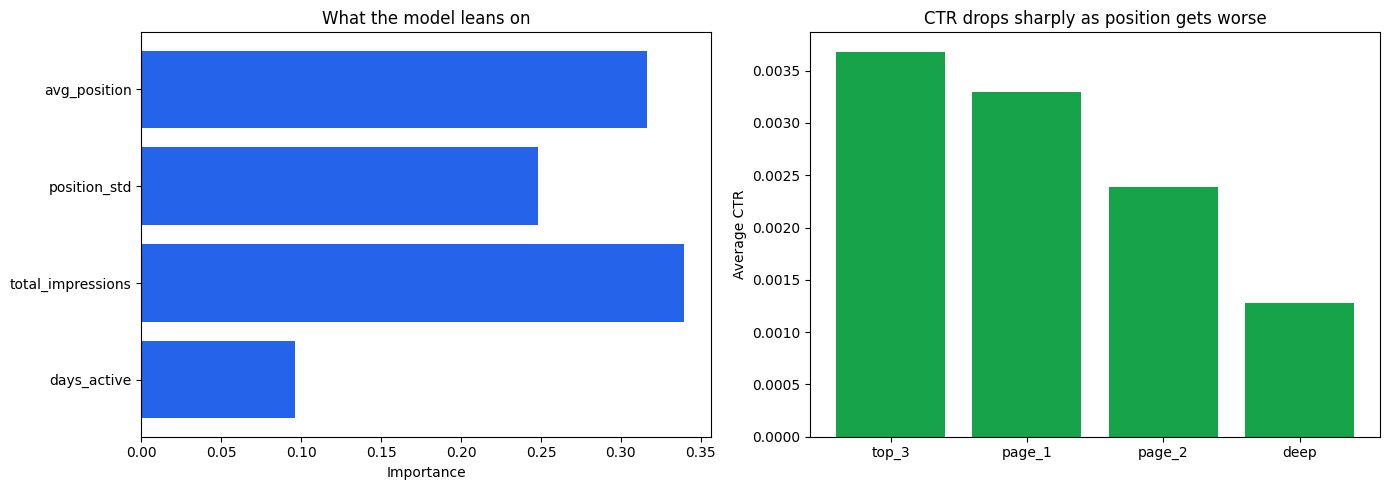

Charts saved to work/outputs/capstone_charts.png


In [16]:
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(features, rf.feature_importances_, color="#2563eb")
axes[0].set_xlabel("Importance")
axes[0].set_title("What the model leans on")
axes[0].invert_yaxis()

bucket_order = ["top_3", "page_1", "page_2", "deep"]
ctr_by_bucket = page_level.groupby("position_bucket")["ctr"].mean().reindex(bucket_order)
axes[1].bar(ctr_by_bucket.index, ctr_by_bucket.values, color="#16a34a")
axes[1].set_ylabel("Average CTR")
axes[1].set_title("CTR drops sharply as position gets worse")

plt.tight_layout()
os.makedirs("work/outputs", exist_ok=True)
plt.savefig("work/outputs/capstone_charts.png", dpi=150)
plt.show()

print("Charts saved to work/outputs/capstone_charts.png")

## ML-12
### 5-minute demo outline
1. (30 sec) The question: which top-ranking pages are wasting visibility
   on poor click-through, and can a model catch them before a human does?
2. (1 min) The data: FlyRank's real search warehouse, one month, one row
   per page after aggregation, 116K pages.
3. (1.5 min) The baseline vs first attempt: a daily-level decision tree
   (Week 5) couldn't beat a simple majority guess, show why (every leaf
   predicted the same class).
4. (1.5 min) The fix: aggregate to monthly, add position stability as a
   feature, a Random Forest genuinely beat the baseline, with position_std
   as the second most important feature.
5. (30 sec) The output: a ranked action list, thousands of high-value
   pages (good rank, real traffic) flagged for review, ready for a
   content team.

### Social-post cut
I spent my ML internship at FlyRank trying to answer one question: which
top-ranking pages are quietly wasting their search visibility? My first
model attempt couldn't beat a simple guess, so I dug into why, fixed the
approach, and got a real (if modest) improvement with a Random Forest.
The output: a ranked list of high-value pages a content team could
actually act on. Full write-up and code linked below.

### Employer-facing summary
Built an end-to-end search-performance analysis on a real 78M-row
production-style warehouse: defined an honest baseline, diagnosed why an
initial model failed to beat it, then improved the feature engineering to
achieve a genuine (if modest) lift. Delivered a ranked, explainable action
list prioritizing high-traffic pages for content review, backed by full
leakage checks and honest limitations reporting.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
